In [2]:
import pandas as pd
import numpy as np

housing = pd.read_csv("../data/processed/cleaned_housing.csv")
housing['Date'] = pd.to_datetime(housing['Date'])
housing['Year'] = housing['Date'].dt.year
housing['Month'] = housing['Date'].dt.month

housing.head()

,Date,RegionName,AveragePrice,SalesVolume,DetachedPrice,SemiDetachedPrice,TerracedPrice,FlatPrice,CashPrice,MortgagePrice,Year,Month
0,1968-01-04,West Midlands Region,3188,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
1,1968-01-04,Yorkshire and The Humber,2553,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
2,1968-01-04,London,4730,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
3,1968-01-04,Northern Ireland,3465,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1
4,1968-01-04,Scotland,2738,84.0,143462.0,75833.0,58017.0,48090.0,94689.0,105153.0,1968,1


In [3]:
features = [
    'Year',
    'Month',
    'SalesVolume',
    'DetachedPrice',
    'SemiDetachedPrice',
    'TerracedPrice',
    'FlatPrice',
    'CashPrice',
    'MortgagePrice'
]

X = housing[features]
y = housing['AveragePrice']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

rmse_lr, r2_lr

(np.float64(31567.690672196226), 0.9412939669803073)

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, r2_rf

(np.float64(22551.13555078786), 0.9700405427935455)

In [7]:
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)
print("-----")
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Linear Regression RMSE: 31567.690672196226
Linear Regression R²: 0.9412939669803073
-----
Random Forest RMSE: 22551.13555078786
Random Forest R²: 0.9700405427935455


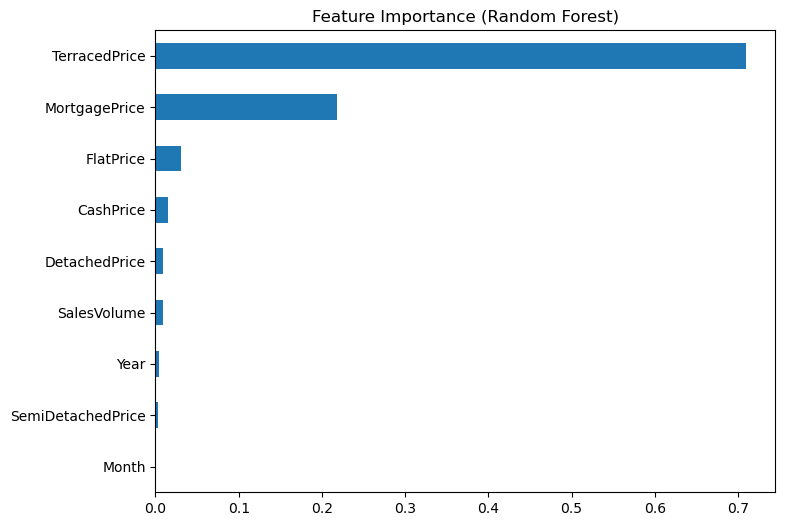

In [8]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

In [9]:
import joblib

joblib.dump(rf, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']

In [10]:
loaded_model = joblib.load("../models/house_price_model.pkl")
loaded_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Results & Interpretation

#### Model Performance Summary

Two regression models were trained to predict UK average house prices:

| Model | RMSE | R² |
|------|------|------|
| Linear Regression | 31,568 | 0.94 |
| Random Forest | 22,551 | 0.97 |

The Random Forest model significantly outperformed Linear Regression, reducing prediction error and explaining approximately **97% of the variance** in house prices.

#### Why Random Forest Performed Better

Linear Regression assumes a simple linear relationship between features and price.
However, housing prices are influenced by complex, non-linear interactions such as:

1.Economic cycles

2.Regional demand differences

3.Property type price gaps

4.Financing behaviour (cash vs mortgage)

Random Forest captures these non-linear relationships, which explains the performance improvement.

#### Key Drivers of House Prices

Feature importance analysis shows that the most influential factors are:

1.Property type prices (Detached, Semi-Detached, Terraced, Flats)

2.Mortgage and Cash purchase prices

3.Sales volume and time (Year/Month)

This confirms that property characteristics and financing behaviour are strong predictors of housing prices.

#### Business Implications

The model demonstrates that machine learning can effectively estimate housing market trends and property values.
Such models could support:

1.Real estate investment decisions

2.Mortgage lending risk assessment

3.Housing market forecasting

4.Property valuation tools